In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from xgboost import XGBClassifier

Importing the Dataset

In [ ]:
spaceship_data = pd.read_csv('/content/train.csv')

In [ ]:
spaceship_data.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


EDA

In [ ]:
spaceship_data['Transported'].value_counts()

,count
Transported,
True,4378
False,4315


Passengers v/s Transported

<Axes: xlabel='Transported', ylabel='count'>

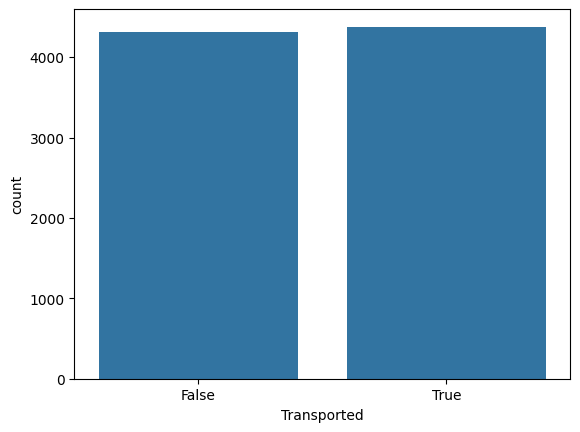

In [ ]:
sns.countplot(x='Transported', data=spaceship_data)

HomePlanet vs Transported

<Axes: xlabel='Transported', ylabel='count'>

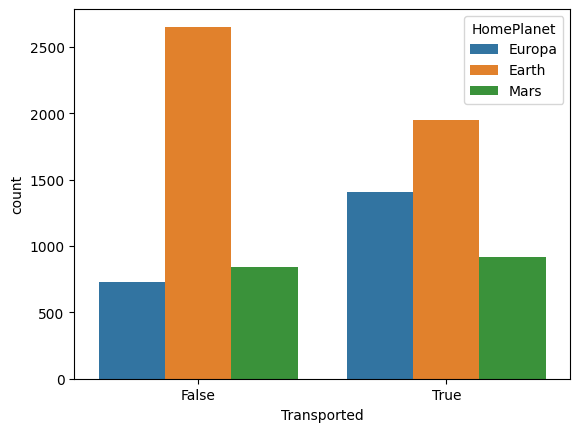

In [ ]:
sns.countplot(x='Transported', hue = 'HomePlanet', data = spaceship_data )

Cryosleep vs Transported

<Axes: xlabel='Transported', ylabel='count'>

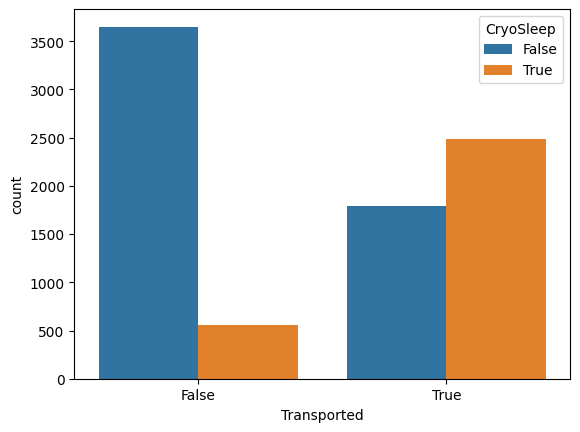

In [ ]:
sns.countplot(x='Transported', hue='CryoSleep', data = spaceship_data)

Cabin Vs Transported

KeyboardInterrupt: 

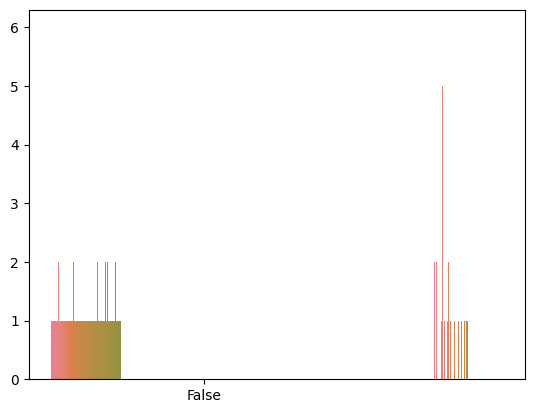

In [ ]:
sns.countplot(x='Transported', hue='Cabin', data = spaceship_data)

Deck vs Transported

In [ ]:
spaceship_data[['Deck','CabinNum','Side']] = spaceship_data['Cabin'].str.split('/', expand = True)

<Axes: xlabel='Transported', ylabel='count'>

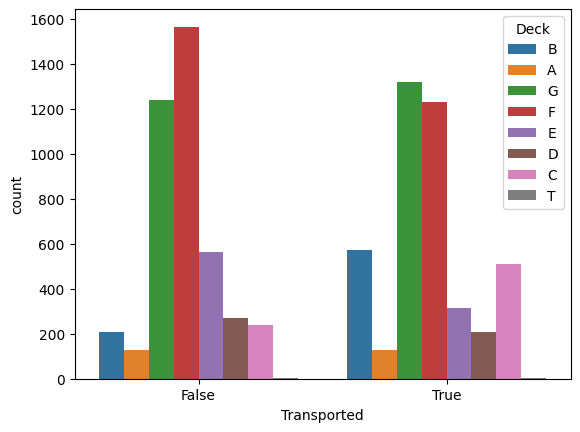

In [ ]:
sns.countplot(x='Transported', hue='Deck', data = spaceship_data)

Spending Features vs Transported

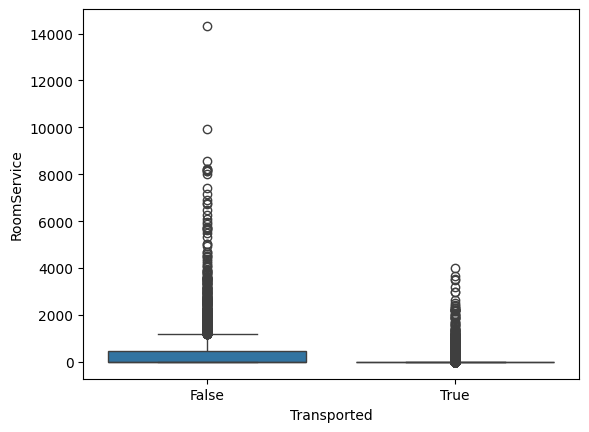

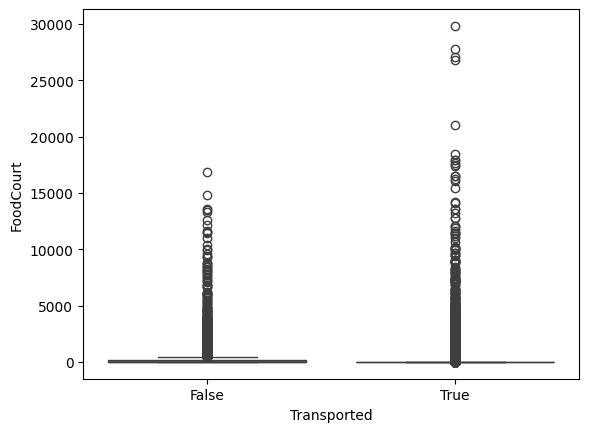

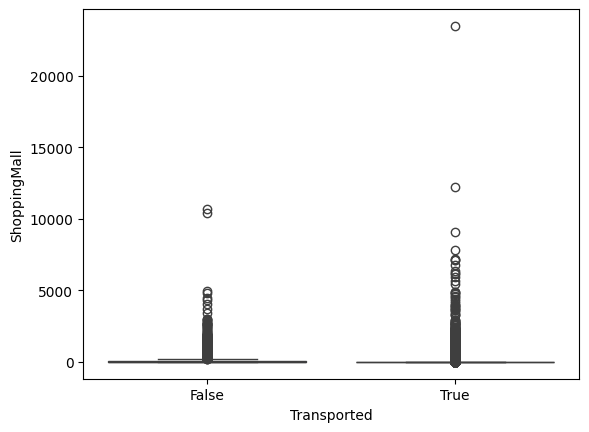

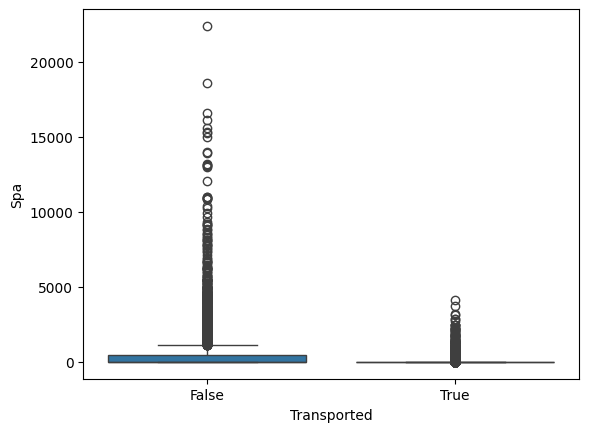

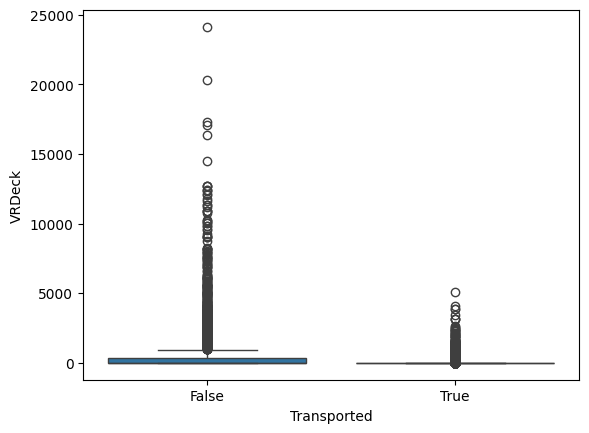

In [ ]:
spend_cols = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']

for i in spend_cols:
  sns.boxplot(x='Transported', y=i, data=spaceship_data)
  plt.show()

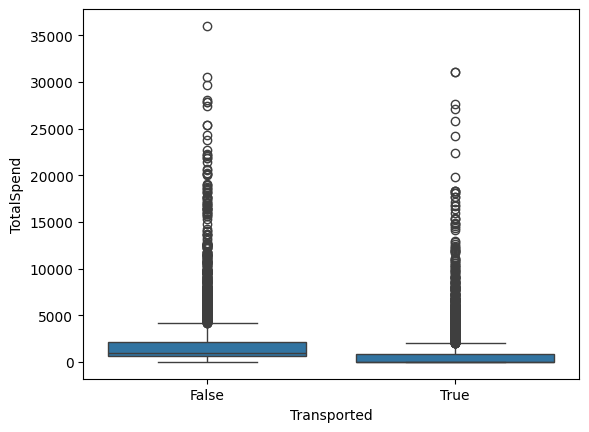

In [ ]:
spaceship_data['TotalSpend'] = spaceship_data[spend_cols].sum(axis=1)

sns.boxplot(x='Transported', y='TotalSpend', data=spaceship_data)
plt.show()

Age vs Transported

<Axes: xlabel='Transported', ylabel='count'>

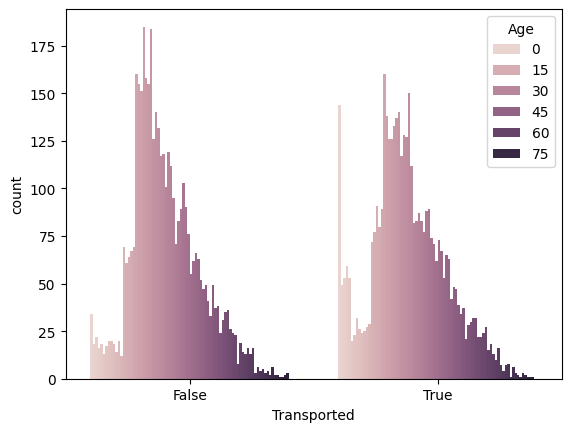

In [ ]:
sns.countplot(x='Transported', hue='Age', data=spaceship_data)

Group Size Analysis

<Axes: xlabel='Transported', ylabel='GroupSize'>

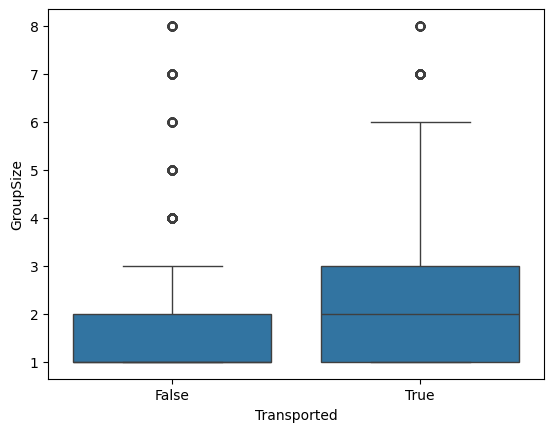

In [ ]:
spaceship_data['Group'] = spaceship_data['PassengerId'].apply(lambda x: x.split('_')[0])
spaceship_data['GroupSize'] = spaceship_data.groupby('Group')['PassengerId'].transform('count')

sns.boxplot(x='Transported', y='GroupSize', data=spaceship_data)

VIP Analysis


<Axes: xlabel='VIP', ylabel='count'>

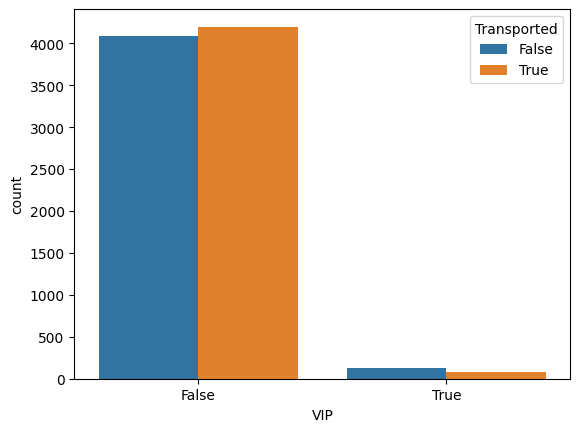

In [ ]:
sns.countplot(x='VIP', hue='Transported', data=spaceship_data)


Missing value Analysis

In [ ]:
spaceship_data.isnull().sum().sort_values(ascending=False)

,0
CryoSleep,217
ShoppingMall,208
VIP,203
HomePlanet,201
Name,200
Cabin,199
Side,199
Deck,199
CabinNum,199
VRDeck,188


In [ ]:
spend_cols = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']

for col in spend_cols:
    spaceship_data[col].fillna(0, inplace=True)

/tmp/ipython-input-3384092287.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  spaceship_data[col].fillna(0, inplace=True)


In [ ]:
spaceship_data['Age'] = spaceship_data['Age'].fillna(spaceship_data['Age'].median())

In [ ]:
spaceship_data['TotalSpend'] = spaceship_data[spend_cols].sum(axis=1)

Cryosleep logic imputation


In [ ]:
spaceship_data['CryoSleep'] = spaceship_data['CryoSleep'].fillna(spaceship_data['TotalSpend'].apply(lambda x : True if x == 0 else False))

/tmp/ipython-input-783447865.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  spaceship_data['CryoSleep'] = spaceship_data['CryoSleep'].fillna(spaceship_data['TotalSpend'].apply(lambda x : True if x == 0 else False))


In [ ]:
spaceship_data['VIP'].fillna(False, inplace=True)

/tmp/ipython-input-3286800472.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  spaceship_data['VIP'].fillna(False, inplace=True)
/tmp/ipython-input-3286800472.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  spaceship_data['VIP'].fillna(False, inplace=True)


In [ ]:
spaceship_data['HomePlanet'].fillna(spaceship_data['HomePlanet'].mode()[0], inplace=True)

/tmp/ipython-input-2636774948.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  spaceship_data['HomePlanet'].fillna(spaceship_data['HomePlanet'].mode()[0], inplace=True)


In [ ]:
spaceship_data['Destination'].fillna(spaceship_data['Destination'].mode()[0], inplace=True)

/tmp/ipython-input-582925636.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  spaceship_data['Destination'].fillna(spaceship_data['Destination'].mode()[0], inplace=True)


In [ ]:
spaceship_data['Deck'].fillna(spaceship_data['Deck'].mode()[0], inplace=True)
spaceship_data['Side'].fillna(spaceship_data['Side'].mode()[0], inplace=True)

/tmp/ipython-input-1542360308.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  spaceship_data['Deck'].fillna(spaceship_data['Deck'].mode()[0], inplace=True)
/tmp/ipython-input-1542360308.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(

In [ ]:
spaceship_data['IsAlone'] = (spaceship_data['GroupSize'] == 1).astype(int)

In [ ]:
spaceship_data.isnull().sum()

,0
PassengerId,0
HomePlanet,0
CryoSleep,0
Cabin,199
Destination,0
Age,0
VIP,0
RoomService,0
FoodCourt,0
ShoppingMall,0


Dropping useless columns

In [ ]:
spaceship_data.drop(['Name', 'PassengerId', 'Group', 'Cabin'], axis=1, inplace=True)

In [ ]:
spaceship_data.drop('CabinNum', axis=1, inplace=True)

Encoding categorical values

In [ ]:
spaceship_data = pd.get_dummies(spaceship_data, drop_first=True)

In [ ]:
spaceship_data.head()

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,TotalSpend,...,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Side_S
0,False,39.0,False,0.0,0.0,0.0,0.0,0.0,False,0.0,...,False,True,True,False,False,False,False,False,False,False
1,False,24.0,False,109.0,9.0,25.0,549.0,44.0,True,736.0,...,False,True,False,False,False,False,True,False,False,True
2,False,58.0,True,43.0,3576.0,0.0,6715.0,49.0,False,10383.0,...,False,True,False,False,False,False,False,False,False,True
3,False,33.0,False,0.0,1283.0,371.0,3329.0,193.0,False,5176.0,...,False,True,False,False,False,False,False,False,False,True
4,False,16.0,False,303.0,70.0,151.0,565.0,2.0,True,1091.0,...,False,True,False,False,False,False,True,False,False,True


Splitting the data

In [ ]:
X = spaceship_data.drop('Transported', axis = 1)
Y = spaceship_data['Transported'].astype(int)

In [ ]:
X

,CryoSleep,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,TotalSpend,GroupSize,...,Destination_PSO J318.5-22,Destination_TRAPPIST-1e,Deck_B,Deck_C,Deck_D,Deck_E,Deck_F,Deck_G,Deck_T,Side_S
0,False,39.0,False,0.0,0.0,0.0,0.0,0.0,0.0,1,...,False,True,True,False,False,False,False,False,False,False
1,False,24.0,False,109.0,9.0,25.0,549.0,44.0,736.0,1,...,False,True,False,False,False,False,True,False,False,True
2,False,58.0,True,43.0,3576.0,0.0,6715.0,49.0,10383.0,2,...,False,True,False,False,False,False,False,False,False,True
3,False,33.0,False,0.0,1283.0,371.0,3329.0,193.0,5176.0,2,...,False,True,False,False,False,False,False,False,False,True
4,False,16.0,False,303.0,70.0,151.0,565.0,2.0,1091.0,1,...,False,True,False,False,False,False,True,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,False,41.0,True,0.0,6819.0,0.0,1643.0,74.0,8536.0,1,...,False,False,False,False,False,False,False,False,False,False
8689,True,18.0,False,0.0,0.0,0.0,0.0,0.0,0.0,1,...,True,False,False,False,False,False,False,True,False,True
8690,False,26.0,False,0.0,0.0,1872.0,1.0,0.0,1873.0,1,...,False,True,False,False,False,False,False,True,False,True
8691,False,32.0,False,0.0,1049.0,0.0,353.0,3235.0,4637.0,2,...,False,False,False,False,False,True,False,False,False,True


In [ ]:
Y

,Transported
0,0
1,1
2,0
3,0
4,1
...,...
8688,0
8689,0
8690,1
8691,0


Train Validation Split

In [ ]:
X_train, X_val, Y_train, Y_val = train_test_split(
    X, Y,
    test_size = 0.2,
    random_state = 42,
    stratify = Y
)

Stratified Kfold Train Validation Split

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = []

for train_index, val_index in skf.split(X, Y):
  X_train_skf = X.iloc[train_index]
  X_val_skf = X.iloc[val_index]
  Y_train_skf = Y.iloc[train_index]
  Y_val_skf = Y.iloc[val_index]


Training a Baseline XGBoost Model

In [ ]:
#XGBOOST
xgb = XGBClassifier(
    n_estimators = 500,
    learning_rate = 0.05,
    max_depth = 6,
    subsample = 0.8,
    colsample_bytree = 0.8,
    random_state = 42,
    eval_metric = 'logloss'
)

xgb.fit(X_train, Y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
val_pred_xgb = xgb.predict(X_val)

In [ ]:
val_pred_xgb

array([1, 1, 0, ..., 1, 0, 0])

In [ ]:
print("Validation Accuracy:", accuracy_score(Y_val, val_pred_xgb))

Validation Accuracy: 0.8085106382978723


Ensembling Random Forest and SVM

In [ ]:
rf = RandomForestClassifier(
    n_estimators = 400,
    max_depth = 12,
    random_state = 42
)

In [ ]:
rf.fit(X_train, Y_train)

RandomForestClassifier(max_depth=12, n_estimators=400, random_state=42)

In [ ]:
rf_pred = rf.predict(X_val)

In [ ]:
print("Random Forest Accuracy:", accuracy_score(Y_val, rf_pred))

Random Forest Accuracy: 0.8010350776308223


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
svm = SVC (
    C = 2,
    kernel = 'rbf',
    probability = True,
    random_state = 42
)

In [ ]:
svm.fit(X_scaled, Y_train)

SVC(C=2, probability=True, random_state=42)

In [ ]:
svm_pred = svm.predict(X_val)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


In [ ]:
print("SVM Accuracy Score", accuracy_score(Y_val, svm_pred))

SVM Accuracy Score 0.5140885566417481


Soft Voting

In [ ]:
ensemble = VotingClassifier(
    estimators = [
        ('rf', rf),
        ('svm', svm),
        ('xgb', xgb)
    ],
    voting = 'soft'
)

In [ ]:
ensemble.fit(X_train, Y_train)

VotingClassifier(estimators=[('rf',
                              RandomForestClassifier(max_depth=12,
                                                     n_estimators=400,
                                                     random_state=42)),
                             ('svm',
                              SVC(C=2, probability=True, random_state=42)),
                             ('xgb',
                              XGBClassifier(base_score=None, booster=None,
                                            callbacks=None,
                                            colsample_bylevel=None,
                                            colsample_bynode=None,
                                            colsample_bytree=0.8, device=None,
                                            early_stopping_rounds=None,
                                            enable_categorical=False...
                                            feature_weights=None, gamma=None,
                                            grow_policy=None,
                                            importance_type=None,
                                            interaction_constraints=None,
                                            learning_rate=0.05, max_bin=None,
                                            max_cat_threshold=None,
                                            max_cat_to_onehot=None,
                                            max_delta_step=None, max_depth=6,
                                            max_leaves=None,
                                            min_child_weight=None, missing=nan,
                                            monotone_constraints=None,
                                            multi_strategy=None,
                                            n_estimators=500, n_jobs=None,
                                            num_parallel_tree=None, ...))],
                 voting='soft')

In [ ]:
val_pred_ensemble = ensemble.predict(X_val)

In [ ]:
print("Ensemble Accuracy:", accuracy_score(Y_val, val_pred_ensemble))

Ensemble Accuracy: 0.8062104657849338


Submission

In [ ]:
test_data = pd.read_csv('/content/test.csv')

In [ ]:
test_ids = test_data['PassengerId']

In [ ]:
test_data[['Deck','CabinNum','Side']] = test_data['Cabin'].str.split('/', expand=True)

In [ ]:
spend_cols = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']

for col in spend_cols:
    test_data[col].fillna(0, inplace=True)

test_data['TotalSpend'] = test_data[spend_cols].sum(axis=1)

/tmp/ipython-input-750115640.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_data[col].fillna(0, inplace=True)


In [ ]:
spend_cols = ['RoomService','FoodCourt','ShoppingMall','Spa','VRDeck']

for col in spend_cols:
    test_data[col].fillna(0, inplace=True)

test_data['TotalSpend'] = test_data[spend_cols].sum(axis=1)

/tmp/ipython-input-750115640.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_data[col].fillna(0, inplace=True)


In [ ]:
test_data['Age'].fillna(spaceship_data['Age'].median(), inplace=True)

/tmp/ipython-input-918493996.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  test_data['Age'].fillna(spaceship_data['Age'].median(), inplace=True)


In [ ]:
test_data['Group'] = test_data['PassengerId'].str.split('_').str[0]
test_data['GroupSize'] = test_data.groupby('Group')['Group'].transform('count')
test_data['IsAlone'] = (test_data['GroupSize'] == 1).astype(int)

In [ ]:
test_data['Group'] = test_data['PassengerId'].str.split('_').str[0]
test_data['GroupSize'] = test_data.groupby('Group')['Group'].transform('count')
test_data['IsAlone'] = (test_data['GroupSize'] == 1).astype(int)

In [ ]:
test_data.drop(['Name','PassengerId','Group','Cabin','CabinNum'], axis=1, inplace=True)

In [ ]:
test_data = pd.get_dummies(test_data, drop_first=True)

# Align columns with training data
test_data = test_data.reindex(columns=X.columns, fill_value=0)

In [ ]:
X_test = spaceship_data.drop('Transported', axis=1)

In [ ]:
final_model = XGBClassifier(
    n_estimators=800,
    learning_rate=0.03,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

final_model.fit(X, Y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.03, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=800, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
test_preds = final_model.predict(test_data)

In [ ]:
test_preds = final_model.predict(test_data)

Final Submission

In [ ]:
submission = pd.DataFrame({
    'PassengerId' : test_ids,
    'Transported' : test_preds.astype(bool)
})

submission.to_csv('submission.csv', index=False)